# Analytics questions

Answers built on the gold star schema (`fact_sales`, `dim_customer`, `dim_product`, `dim_date`).
Run the pipeline first: bronze, silver, gold.

In [2]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
from pyspark.sql import functions as F

from ETL import config
from ETL.spark import get_spark

spark = get_spark()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/10/07 13:25:30 WARN Utils: Your hostname, Natalias-MacBook-Pro-480.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.67 instead (on interface en0)
26/10/07 13:25:30 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/10/07 13:25:31 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/10/07 13:25:31 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [4]:
def read_gold(table):
    return spark.read.parquet(str(config.GOLD_DIR / f"{table}.{config.OUTPUT_FORMAT}"))

In [5]:
fact_sales = read_gold("fact_sales")
dim_customer = read_gold("dim_customer")
dim_product = read_gold("dim_product")
dim_date = read_gold("dim_date")

## 1. Top 10 countries with the most customers

Counted from `dim_customer`. The `-1` row is left out, and so are the 13 customers whose country is unknown

In [6]:
customers_by_country = (
    dim_customer
    .filter(F.col("customer_key") != config.UNKNOWN_KEY)
    .filter(F.col("country") != config.UNKNOWN)
    .groupBy("country")
    .agg(F.count("*").alias("customers"))
    .orderBy(F.desc("customers"), "country")
)
customers_by_country.show(10)

unknown_country = dim_customer.filter(
    (F.col("customer_key") != config.UNKNOWN_KEY) & (F.col("country") == config.UNKNOWN)
).count()
print(f"Customers with unknown country (not ranked): {unknown_country}")

+--------------+---------+
|       country|customers|
+--------------+---------+
|United Kingdom|     3950|
|       Germany|       95|
|        France|       87|
|         Spain|       29|
|       Belgium|       22|
|      Portugal|       19|
|   Switzerland|       19|
|         Italy|       15|
|       Finland|       12|
|        Norway|       10|
+--------------+---------+
only showing top 10 rows
Customers with unknown country (not ranked): 13


**Answer.** The United Kingdom has 3,950 customers, about 90% of the customer base. Next are Germany (95),
France (87), Spain (29), Belgium (22), Portugal and Switzerland (19 each), Italy (15), Finland (12) and Norway (10).

## 2. Revenue distribution by country

Net revenue is `SUM(line_amount)` over all lines, so cancellations and other negative lines are subtracted.
Order lines with no customer are shown as their own group, "No customer recorded", instead of being hidden in "Unknown".

In [7]:
sales_with_country = fact_sales.join(dim_customer, "customer_key").withColumn(
    "country",
    F.when(F.col("customer_key") == config.UNKNOWN_KEY, "No customer recorded")
    .otherwise(F.col("country")),
)
total_revenue = fact_sales.agg(F.sum("line_amount")).first()[0]

In [8]:
revenue_by_country = (
    sales_with_country
    .groupBy("country")
    .agg(F.sum("line_amount").alias("net_revenue"))
    .withColumn("share_pct", F.round(100 * F.col("net_revenue") / F.lit(total_revenue), 2))
    .orderBy(F.desc("net_revenue"))
)

In [9]:
print(f"Total net revenue: {total_revenue:,.2f}")
revenue_by_country.show(40, truncate=False)

Total net revenue: 12,921,024.05
+--------------------+-----------+---------+
|country             |net_revenue|share_pct|
+--------------------+-----------+---------+
|United Kingdom      |10010896.66|77.48    |
|No customer recorded|634278.66  |4.91     |
|Netherlands         |504348.98  |3.90     |
|Ireland             |333923.60  |2.58     |
|Germany             |303944.75  |2.35     |
|France              |278830.00  |2.16     |
|Australia           |206420.13  |1.60     |
|Sweden              |95026.91   |0.74     |
|Switzerland         |70975.05   |0.55     |
|Japan               |68755.28   |0.53     |
|Spain               |65746.97   |0.51     |
|Belgium             |52944.59   |0.41     |
|Norway              |50002.31   |0.39     |
|Portugal            |41519.28   |0.32     |
|Unknown             |37635.91   |0.29     |
|Finland             |27279.75   |0.21     |
|Channel Islands     |22923.70   |0.18     |
|Italy               |18924.97   |0.15     |
|Denmark             |

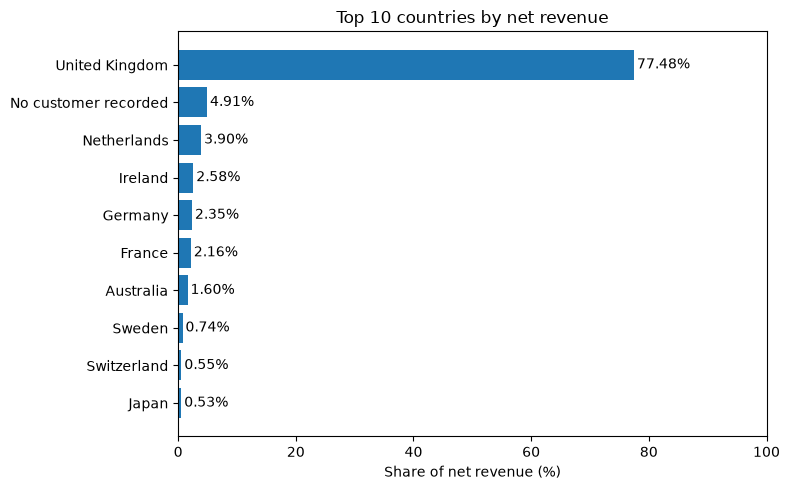

In [10]:
top = revenue_by_country.limit(10).collect()
countries = [row.country for row in top][::-1]
shares = [row.share_pct for row in top][::-1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(countries, shares)
ax.set_xlim(0, 100)
ax.set_xlabel("Share of net revenue (%)")
ax.set_title("Top 10 countries by net revenue")
for y, share in enumerate(shares):
    ax.text(float(share) + 0.5, y, f"{share}%", va="center")
plt.tight_layout()
plt.show()

**Answer.** Total net revenue is 12.92M. Revenue is concentrated in UK (77.5%).
After that come orders with no customer recorded (4.9%), the Netherlands (3.9%), Ireland (2.6%), Germany (2.4%),
France (2.2%) and Australia (1.6%). Every other country is below 1%.

## 3. Relationship between average unit price of products and their sales volume.

Price is `dim_product.unit_price`, the median of each product's listed prices. Volume is units sold (`SUM(quantity)`
on `sale` lines). Products with no usable price are left out.

In [11]:
units_sold = (
    fact_sales
    .filter(F.col("line_type") == "sale")
    .groupBy("product_key")
    .agg(F.sum("quantity").alias("units_sold"))
)

In [12]:
price_vs_volume = (
    dim_product
    .filter(F.col("unit_price").isNotNull())
    .join(units_sold, "product_key")
    .select("stock_code", F.col("unit_price").cast("double").alias("unit_price"), "units_sold")
)

In [13]:
price_vs_volume.select(
    F.round(F.corr("unit_price", "units_sold"), 3).alias("corr_price_units"),
    F.round(F.corr("unit_price", F.log10("units_sold")), 3).alias("corr_price_log_units"),
).show()

+----------------+--------------------+
|corr_price_units|corr_price_log_units|
+----------------+--------------------+
|             0.0|               0.015|
+----------------+--------------------+



In [14]:

price_bands = (
    price_vs_volume
    .withColumn("band", F.least(F.floor("unit_price"), F.lit(4)))
    .withColumn("price_band", F.concat(F.col("band"), F.lit(" to "), F.col("band") + 1))
    .groupBy("price_band")
    .agg(
        F.count("*").alias("products"),
        F.round(F.avg("units_sold")).alias("avg_units_sold"),
        F.percentile_approx("units_sold", 0.5).alias("median_units_sold"),
    )
    .orderBy("price_band")
)
price_bands.show()

+----------+--------+--------------+-----------------+
|price_band|products|avg_units_sold|median_units_sold|
+----------+--------+--------------+-----------------+
|    0 to 1|     594|        1472.0|              339|
|    1 to 2|     786|        1420.0|              449|
|    2 to 3|     987|        1552.0|              413|
|    3 to 4|     819|        1414.0|              432|
|    4 to 5|     639|        1503.0|              453|
+----------+--------+--------------+-----------------+



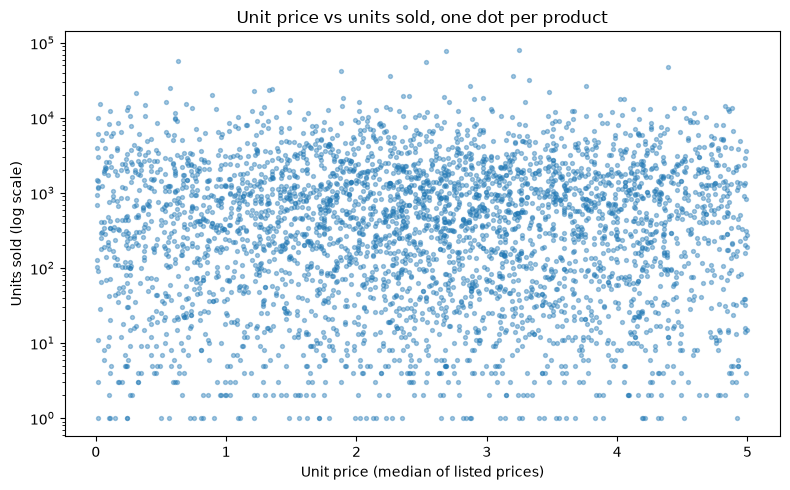

In [15]:
points = price_vs_volume.collect()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter([p.unit_price for p in points], [p.units_sold for p in points], s=8, alpha=0.4)
ax.set_yscale("log")
ax.set_xlabel("Unit price (median of listed prices)")
ax.set_ylabel("Units sold (log scale)")
ax.set_title("Unit price vs units sold, one dot per product")
plt.tight_layout()
plt.show()

**Answer.** There is no relationship. The correlation is 0.00 against units sold and 0.015 against log units sold.
Every price band sells about the same: on average 1,400 to 1,550 units per product, with a median of 340 to 450.
The scatter plot is an even cloud with no slope.

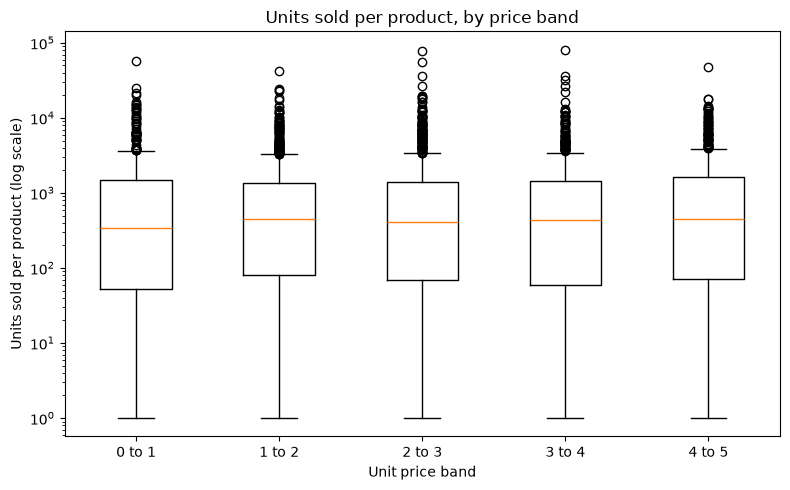

In [16]:
bands = ["0 to 1", "1 to 2", "2 to 3", "3 to 4", "4 to 5"]
units_by_band = [[] for _ in bands]
for p in points:
    units_by_band[min(int(p.unit_price), 4)].append(p.units_sold)

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(units_by_band, tick_labels=bands)
ax.set_yscale("log")
ax.set_xlabel("Unit price band")
ax.set_ylabel("Units sold per product (log scale)")
ax.set_title("Units sold per product, by price band")
plt.tight_layout()
plt.show()

The box plot shows the same: the median product sells about 340 to 450 units in every price band,
and the boxes (middle 50% of products) cover the same range. Cheaper products don't sell more.

## 4. Top 3 products with the maximum unit price drop in the last month.

**This can't be answered from the data.** A price drop needs a product's price at two points in time.
Why?

- `products.csv` has no date column. 1,321 codes have several prices, but nothing says when each one applied,
  and the rows are in no time order.
- `orders.csv` has no price, so the price actually paid on each order is unknown.

The model has to pick one price per product (the median), so every product has exactly one price in every month.

In [17]:
silver_products = spark.read.parquet(str(config.SILVER_DIR / f"products.{config.OUTPUT_FORMAT}"))
print("Columns in products:", silver_products.columns)

prices_per_code = silver_products.groupBy("stock_code").agg(F.count("*").alias("prices"))
print("Codes with more than one listed price:", prices_per_code.filter("prices > 1").count())

prices_per_product = fact_sales.groupBy("product_key").agg(
    F.countDistinct("unit_price").alias("prices")
)
print("Products with more than one price in fact_sales:", prices_per_product.filter("prices > 1").count())

Columns in products: ['stock_code', 'description', 'unit_price']
Codes with more than one listed price: 1321
Products with more than one price in fact_sales: 0
